# White Mussel Independent CPUE and Morphometric Analysis:

## A. CATCH-PER-UNIT-EFFORT ANALYSES:

IMPORTING PACKAGES AND SUBMODULES:

In [58]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from scipy.stats import shapiro, norm
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, kruskal
import scikit_posthocs as sp

1. FILE PATHS:

In [14]:
BASE_DIR = Path.cwd()
print(BASE_DIR)

BASE_DIR = Path(
    r"C:/Users/Mahlatse/Documents/white_mussel_and_rock_lobster_project/python_scripts/white_mussel-and-west_coast_rock_lobster_study"
)

DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"

RESULTS_DIR.mkdir(exist_ok=True)

C:\Users\Mahlatse\Documents\white_mussel_and_rock_lobster_project\python_scripts\white_mussel-and-west_coast_rock_lobster_study


2. LOAD DATA:

Data exploration:

There are 1447 observations of mussels_collected and cpue values across harvest_area, seasonal and monthly groups.
There are two levels to the harvest area variable. 21 years of data from 2002 to 2023 for the paternoster area.
There only exists two missing values for mussels collected, and 0 under cpue.

2.1. White-mussel CPUE data import:

In [23]:
cpue = pd.read_csv(DATA_DIR / "wm_cpue_processed.csv")
cpue

,harvest_area,year,month,day,season,season_year,mussels_collected,cpue_(no_per_hour)
0,Paternoster,2002,9,6.0,Summer,Summer2002,2000.0,72.73
1,Paternoster,2002,10,7.0,Summer,Summer2002,2000.0,71.43
2,Paternoster,2002,11,6.0,Summer,Summer2002,2000.0,66.67
3,Paternoster,2002,12,4.0,Summer,Summer2002,2000.0,66.67
4,Paternoster,2002,7,25.0,Winter,Winter2002,1950.0,44.32
...,...,...,...,...,...,...,...,...
1443,Paternoster,2023,8,18.0,Winter,Winter2023,3180.0,117.78
1444,Paternoster,2023,8,28.0,Winter,Winter2023,1000.0,222.22
1445,Paternoster,2023,8,29.0,Winter,Winter2023,1600.0,133.33
1446,Paternoster,2023,8,30.0,Winter,Winter2023,2500.0,208.33


2.2. White-mussel Morphometric data import:

In [24]:
morph = pd.read_csv(DATA_DIR / "wm_morpho_processed.csv")
morph

,site,date,year,source_type,length_mm,breadth_mm,mass_g
0,PAT01A,2009-07-24,2009,Survey,40.0,61.0,36.0
1,PAT01A,2009-07-24,2009,Survey,42.0,67.0,41.0
2,PAT01A,2009-07-24,2009,Survey,39.0,61.0,32.0
3,PAT01A,2009-07-24,2009,Survey,39.0,55.0,25.0
4,PAT01A,2009-07-24,2009,Survey,29.0,43.0,25.0
...,...,...,...,...,...,...,...
3294,Unknown F,2012-10-15,2012,Commercial,NaN,62.0,NaN
3295,Unknown F,2012-10-15,2012,Commercial,NaN,68.0,NaN
3296,Unknown F,2012-10-15,2012,Commercial,NaN,59.0,NaN
3297,Unknown F,2012-10-15,2012,Commercial,NaN,72.0,NaN


3. Cleaning the columns of the data files:

In [69]:
def clean_cols(df):
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

cpue = clean_cols(cpue)
morph = clean_cols(morph)

cpue.columns = cpue.columns.str.strip()

cpue["year"] = cpue["year"].astype(str)
cpue["season"] = cpue["season"].astype(str)
cpue["cpue"] = cpue["cpue_(no_per_hour)"]

# adjust this if your column name differs slightly
cpue_col = "cpue_(no_per_hour)"

In [27]:
print("CPUE exists:", (DATA_DIR / "wm_cpue_processed.csv").exists())
print("MORPH exists:", (DATA_DIR / "wm_morpho_processed.csv").exists())

print("\nFiles in data folder:")
print(list(DATA_DIR.glob("*.csv")))

CPUE exists: True
MORPH exists: True

Files in data folder:
[WindowsPath('C:/Users/Mahlatse/Documents/white_mussel_and_rock_lobster_project/python_scripts/white_mussel-and-west_coast_rock_lobster_study/data/wm_cpue_processed.csv'), WindowsPath('C:/Users/Mahlatse/Documents/white_mussel_and_rock_lobster_project/python_scripts/white_mussel-and-west_coast_rock_lobster_study/data/wm_morpho_processed.csv')]


4. LOG10 TRANSFORMATION:

In [73]:
cpue["log_cpue"] = np.log10(cpue[cpue_col] + 1)

print(cpue[[cpue_col, "log_cpue"]].head())

   cpue_(no_per_hour)  log_cpue
0               72.73  1.867644
1               71.43  1.859918
2               66.67  1.830396
3               66.67  1.830396
4               44.32  1.656290


In [74]:
# Variable storing the log10 transformed values that will be useful in later analyses.

cpue_log10 = cpue["log_cpue"] = np.log10(cpue[cpue_col] + 1)

5. SHAPIRO-WILK NORMALITY TEST (RAW vs LOG):

In [75]:
raw_test = shapiro(cpue[cpue_col].dropna())
log_test = shapiro(cpue["log_cpue"].dropna())

print("\nRAW CPUE:")
print(raw_test)

print("\nLOG10 CPUE:")
print(log_test)


RAW CPUE:
ShapiroResult(statistic=np.float64(0.781081364372285), pvalue=np.float64(8.815421479826261e-40))

LOG10 CPUE:
ShapiroResult(statistic=np.float64(0.9163494366324664), pvalue=np.float64(3.584211782353115e-27))


In [76]:
alpha = 0.05

if log_test.pvalue > alpha:
    print("\n✔ Log-transformed CPUE is approximately normal → use ANOVA")
else:
    print("\n✖ Still not normal → proceed to non-parametric test")


✖ Still not normal → proceed to non-parametric test


### Descriptives:

In [124]:
def run_master_grouped(df, group_col, cols,
                       desc_out="descriptives.csv",
                       norm_out="normality.csv"):

    desc_all = []
    norm_all = []

    for group, sub_df in df.groupby(group_col):

        for col in cols:

            if sub_df[col].dropna().empty:
                continue

            # -------------------
            # Descriptives
            # -------------------
            desc = descriptive(sub_df, col)
            desc[group_col] = group
            desc["variable"] = col
            desc_all.append(desc)

            # -------------------
            # Normality
            # -------------------
            norm = shapiro_test(sub_df, col)
            norm[group_col] = group
            norm["variable"] = col
            norm_all.append(norm)

            # -------------------
            # Plots (optional)
            # -------------------
            plot_hist(sub_df, col, title=f"{col} ({group})")
            plot_qq(sub_df, col, title=f"{col} ({group})")

    # convert to DataFrames
    desc_df = pd.DataFrame(desc_all)
    norm_df = pd.DataFrame(norm_all)

    # -------------------
    # OVERWRITE CSV FILES
    # -------------------
    desc_df.to_csv(desc_out, index=False)
    norm_df.to_csv(norm_out, index=False)

    print(f"Saved: {desc_out}")
    print(f"Saved: {norm_out}")

    return desc_df, norm_df

In [34]:
# =========================================================
# 4. AUTO DETECT VARIABLES
# =========================================================

cpue_vars = [
    "mussels_collected",
    "cpue_(no_per_hour)"
]

morph_vars = [
    "length_mm",
    "breadth_mm",
    "mass_g"
]

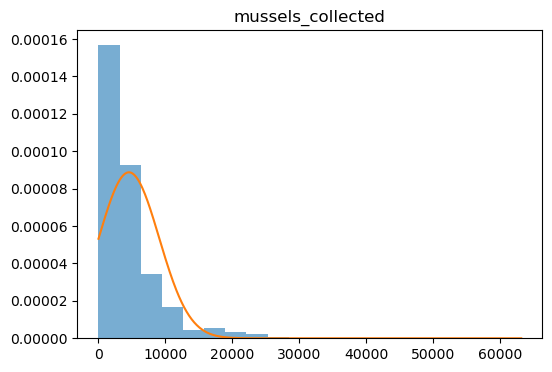

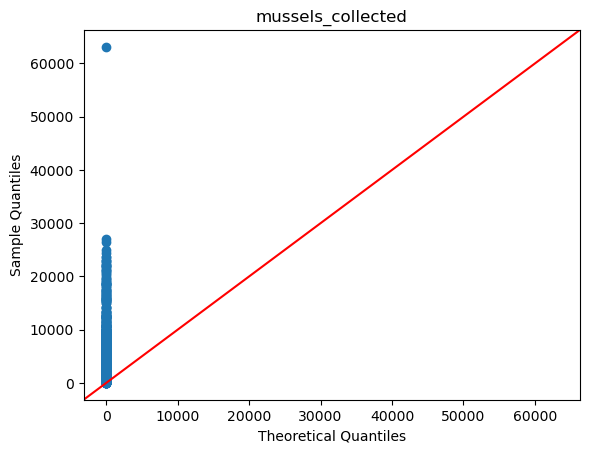

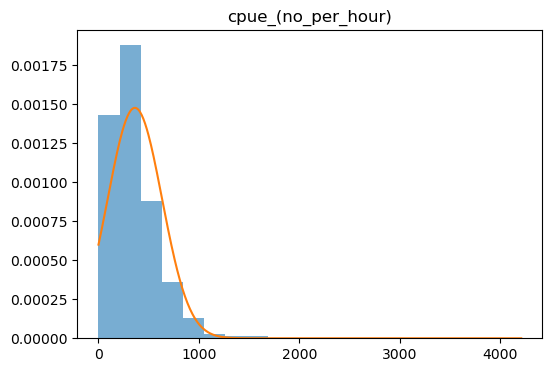

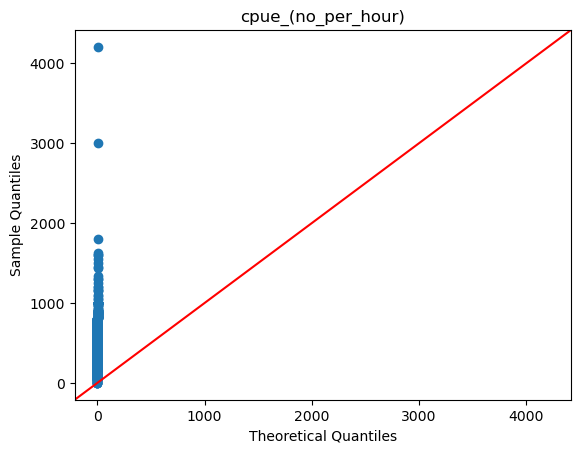

In [35]:
# =========================================================
# 5. CPUE ANALYSIS
# =========================================================

cpue_desc, cpue_norm = run_master(cpue, cpue_vars)

cpue_desc.to_csv(RESULTS_DIR / "cpue_descriptives.csv", index=False)
cpue_norm.to_csv(RESULTS_DIR / "cpue_normality.csv", index=False)

In [51]:
# =========================================================
# 6. NON-PARAMETRIC TEST (IF MONTH OR GROUP EXISTS)
# =========================================================

# ensure grouping variable exists
group_col = "month"

cpue = cpue.dropna(subset=["log_cpue", group_col])

groups = [g["log_cpue"].values for _, g in cpue.groupby(group_col)]

kruskal_result = kruskal(*groups)

print("\nKruskal-Wallis test result:")
print(kruskal_result)

if kruskal_result.pvalue < 0.05:
    print("\n✔ Significant differences between groups (non-parametric)")
else:
    print("\n✖ No significant differences between groups")


Kruskal-Wallis test result:
KruskalResult(statistic=np.float64(55.80269251287856), pvalue=np.float64(5.523277607370176e-08))

✔ Significant differences between groups (non-parametric)


Interpretation:

CPUE differs significantly between months (F₁₁,₁₃₉₃ = 3.45, p < 0.001).
This means CPUE is not constant across the year (there is seasonal variation).
At least one month has a significantly different CPUE compared to others.
Most variation in CPUE occurs within months, not between months.
A Tukey post-hoc test is needed to identify which specific months differ.

### Analysis across groups:

In [53]:
groups_year = [g["cpue"].dropna().values for _, g in cpue.groupby("year")]

kw_year = kruskal(*groups_year)

print("Kruskal-Wallis (Year):", kw_year)

Kruskal-Wallis (Year): KruskalResult(statistic=np.float64(275.4057184955033), pvalue=np.float64(8.246209390178989e-47))


Kruskal–Wallis showed a highly significant difference in CPUE between years (H = 275.41, p < 0.001), indicating strong inter-annual variability in CPUE across the study period.

In [78]:
df_year = cpue.dropna(subset=["cpue", "year"])

dunn_year = sp.posthoc_dunn(
    df_year,
    val_col="cpue",
    group_col="year",
    p_adjust="bonferroni"
)

# =========================================================
# Extract ONLY significant pairs (p < 0.05)
# =========================================================
significant_pairs = []

for i in dunn_year.index:
    for j in dunn_year.columns:
        if i != j and dunn_year.loc[i, j] < 0.05:
            significant_pairs.append({
                "Year 1": i,
                "Year 2": j,
                "p-value": dunn_year.loc[i, j]
            })

sig_year_df = pd.DataFrame(significant_pairs).drop_duplicates()

# sort most significant first
sig_year_df = sig_year_df.sort_values("p-value")

print("\nSignificant Year Differences (Dunn post-hoc):")
print(sig_year_df)


Significant Year Differences (Dunn post-hoc):
    Year 1 Year 2       p-value
139   2020   2019  2.038249e-11
131   2019   2020  2.038249e-11
120   2018   2020  5.598066e-11
138   2020   2018  5.598066e-11
153   2023   2018  5.054922e-10
..     ...    ...           ...
15    2003   2014  4.586135e-02
26    2004   2013  4.615892e-02
85    2013   2004  4.615892e-02
64    2009   2005  4.962857e-02
34    2005   2009  4.962857e-02

[156 rows x 3 columns]


In [54]:
groups_season = [g["cpue"].dropna().values for _, g in cpue.groupby("season")]

kw_season = kruskal(*groups_season)

print("Kruskal-Wallis (Season):", kw_season)

Kruskal-Wallis (Season): KruskalResult(statistic=np.float64(6.9792557381164615), pvalue=np.float64(0.008245989452727125))


CPUE also differed significantly between seasons (H = 6.98, p = 0.008), suggesting that CPUE varies across seasonal cycles, although the effect is much weaker than the year-to-year variation.

In [61]:
df_season = cpue.dropna(subset=["cpue", "season"])

dunn_season = sp.posthoc_dunn(
    df_season,
    val_col="cpue",
    group_col="season",
    p_adjust="bonferroni"
)

significant_pairs_season = []

for i in dunn_season.index:
    for j in dunn_season.columns:
        if i != j and dunn_season.loc[i, j] < 0.05:
            significant_pairs_season.append({
                "Season 1": i,
                "Season 2": j,
                "p-value": dunn_season.loc[i, j]
            })

sig_season_df = pd.DataFrame(significant_pairs_season).drop_duplicates()
sig_season_df = sig_season_df.sort_values("p-value")

print("\nSignificant Season Differences:")
print(sig_season_df)


Significant Season Differences:
  Season 1 Season 2   p-value
0   Summer   Winter  0.008246
1   Winter   Summer  0.008246


In [79]:
all_results = []

for yr, df_year in cpue.groupby("year"):

    # drop missing values within each year
    df_season = df_year.dropna(subset=["cpue", "season"])

    # skip years with too few groups
    if df_season["season"].nunique() < 2:
        continue

    # Dunn test (season differences within this year)
    dunn_season = sp.posthoc_dunn(
        df_season,
        val_col="cpue",
        group_col="season",
        p_adjust="bonferroni"
    )

    # extract significant pairs
    for i in dunn_season.index:
        for j in dunn_season.columns:
            if i != j and dunn_season.loc[i, j] < 0.05:
                all_results.append({
                    "Year": yr,
                    "Season 1": i,
                    "Season 2": j,
                    "p-value": dunn_season.loc[i, j]
                })

# convert to dataframe
sig_season_by_year = pd.DataFrame(all_results)

# clean + sort
if not sig_season_by_year.empty:
    sig_season_by_year = sig_season_by_year.sort_values(["Year", "p-value"])

print("\nSignificant Season Differences Within Each Year:")
print(sig_season_by_year)


Significant Season Differences Within Each Year:
    Year Season 1 Season 2   p-value
0   2007   Summer   Winter  0.015495
1   2007   Winter   Summer  0.015495
2   2008   Summer   Winter  0.000030
3   2008   Winter   Summer  0.000030
4   2012   Summer   Winter  0.017662
5   2012   Winter   Summer  0.017662
6   2015   Summer   Winter  0.000326
7   2015   Winter   Summer  0.000326
8   2018   Summer   Winter  0.000060
9   2018   Winter   Summer  0.000060
10  2019   Summer   Winter  0.022535
11  2019   Winter   Summer  0.022535


This just shows the years where a significant difference in cpue was observed between summer and winter seasons with change in time (in years). Remember 21 years of data from 2002 to 2023 for the paternoster area. Approximately 28,57 % of the period between 2002 to 2023 saw a difference in cpue across seasons.

### Strength ranking:

In [55]:
plot_df = cpue.groupby("year").agg({
    "mussels_collected": "sum",
    "cpue": "mean"
}).reset_index()

In [99]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


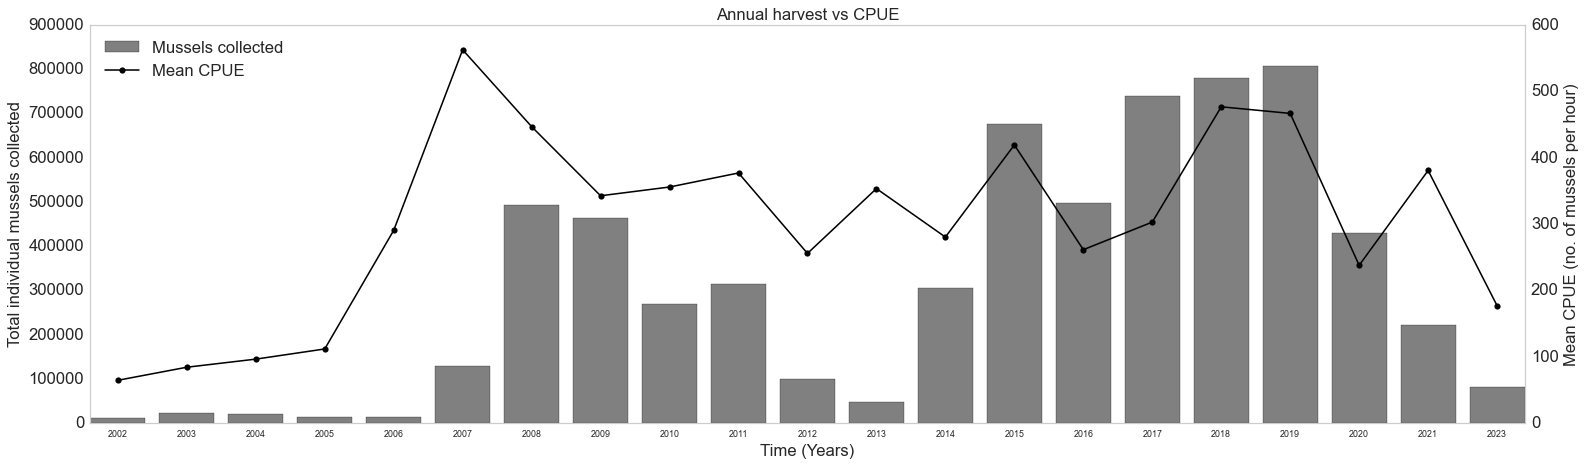

In [122]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(20,6))

# -------------------------
# Primary axis (bars)
# -------------------------
bars = ax1.bar(
    plot_df["year"],
    plot_df["mussels_collected"],
    color="gray",
    label="Mussels collected"
)

ax1.set_ylabel("Total individual mussels collected", fontsize = 15)
ax1.set_xlabel("Time (Years)", fontsize = 15)
plt.yticks(fontsize = 15)

# -------------------------
# Secondary axis (line)
# -------------------------
ax2 = ax1.twinx()

line = ax2.plot(
    plot_df["year"],
    plot_df["cpue"],
    color="black",
    marker="o",
    label="Mean CPUE"
)

ax2.set_ylabel("Mean CPUE (no. of mussels per hour)", fontsize = 15)

# -------------------------
# Title + grid
# -------------------------
plt.title("Annual harvest vs CPUE", fontsize = 15)
plt.yticks(fontsize = 15)
ax1.grid(False)

# -------------------------
# Combined legend (IMPORTANT FIX)
# -------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left", fontsize = 15)

plt.xticks(fontsize = 15)
plt.tight_layout()
plt.grid(False)
plt.show()

## B. MORPHOMETRIC ANALYSES:

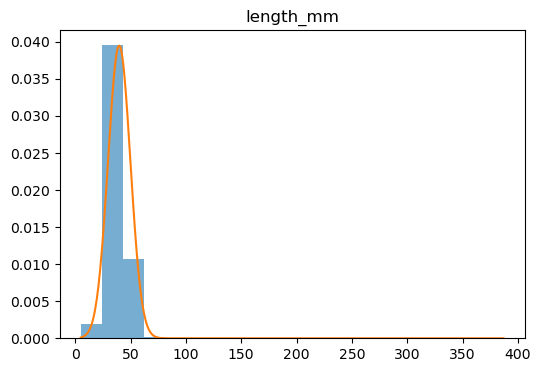

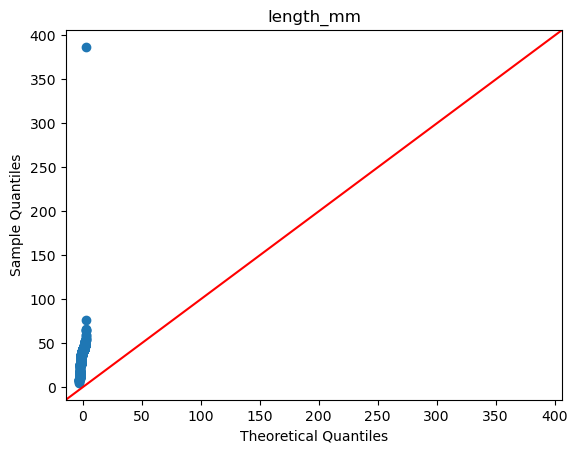

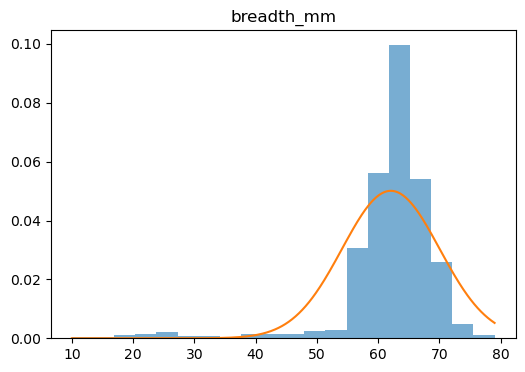

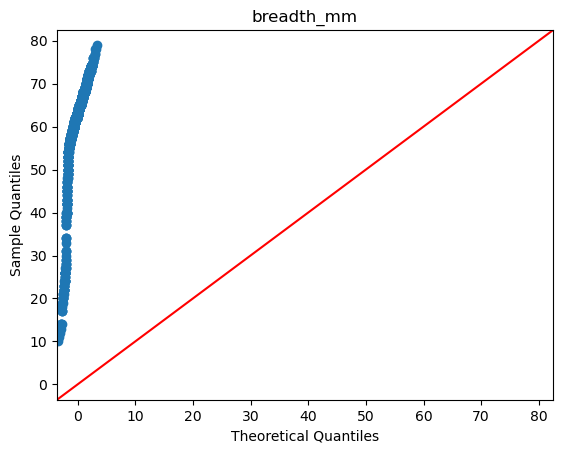

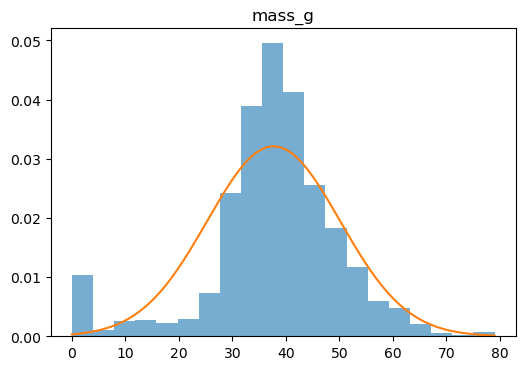

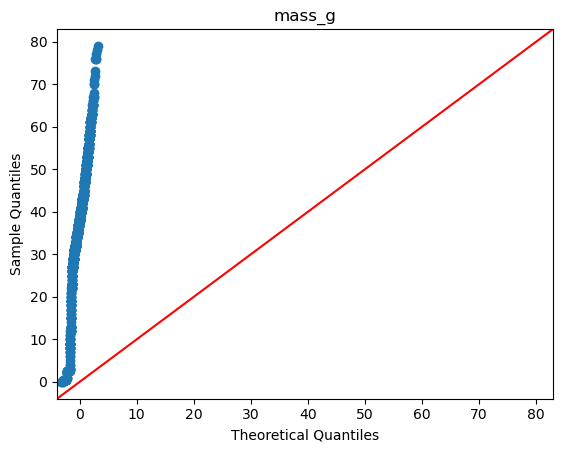

In [39]:
# =========================================================
# 8. MORPHOMETRIC ANALYSIS
# =========================================================

morph_desc, morph_norm = run_master(morph, morph_vars)

morph_desc.to_csv(RESULTS_DIR / "morph_descriptives.csv", index=False)
morph_norm.to_csv(RESULTS_DIR / "morph_normality.csv", index=False)

In [ ]:
# =========================================================
# 9. OPTIONAL: MORPHOMETRIC RELATIONSHIPS
# =========================================================

import seaborn as sns

sns.regplot(data=morph, x="length_mm", y="breadth_mm")
plt.title("Length vs Breadth")
plt.show()

sns.regplot(data=morph, x="length_mm", y="mass_g")
plt.title("Length vs Mass")
plt.show()


# =========================================================
# DONE
# =========================================================

print("ANALYSIS COMPLETE. RESULTS SAVED.")